# Task 2 — Leaderboard Challenge: an Autoformer forecaster

AI651 · PA1 · Task 2

**Goal.** Forecast the next **168** values (`time_idx` 43657 … 43824) of an anonymised univariate
series with an **Autoformer**. The model must contain both Autoformer mechanisms:

1. **Series decomposition**: a moving-average trend/seasonal split, repeated inside every block.
2. **Auto-Correlation**: period-level dependency discovery. FFT delay scores pick the top-k lags,
   and the model aggregates time-shifted copies of the values instead of point-wise attention.

**Leaderboard score** = RMSE + α·P + β·E (P = trainable parameters, E = training epochs).
Fitting the four published top rows gives α ≈ 1.9e-9 and β ≈ 5e-4 (see the switches cell).
Both penalties are tiny next to RMSE differences, so accuracy dominates. The model is still
compact, and the number of epochs is chosen on validation.

**This is version 2 (v2).** Version 1 (first leaderboard submission: RMSE 99.09, 5-seed
ensemble of `log1p|full+roll`, 15 epochs) chose its settings on the average of 26 validation
weeks. The leaderboard week comes right after the last of those weeks, in a much more volatile
regime: the last 12 validation weeks have 2–3× the spread and spikes above 400. v2 therefore:

1. makes decisions on the **12 most recent weeks** (same regime as the leaderboard week) and
   still reports all 26;
2. trains 5 seeds per candidate for up to 25 epochs (v1's chosen epoch was its maximum, 15);
3. tests whether **blending** the log-target ensemble with the raw-target ensemble, and a
   single scale factor, reduce the damping of peaks that a log-target model shows. The blend
   weight and scale are judged by **leave-one-week-out cross-validation**, not by in-sample fit;
4. compares the v2 recipe with the exact v1 recipe on the same weeks, so resubmitting is an
   evidence-based decision.

The ablations for the report (external-data ablation, occlusion, model size) are in the v1
notebook. Sections 0–5 here are identical to v1.

**Attribution.** The architecture follows Wu et al. (2021), *Autoformer: Decomposition
Transformers with Auto-Correlation for Long-Term Series Forecasting*, §§3.1–3.2, and the
structure of the authors' reference implementation (github.com/thuml/Autoformer: series_decomp,
AutoCorrelation, encoder/decoder layers, trend accumulation). Differences from that code:
delays are chosen **per example** (not shared across the batch during training), and the
aggregation reads `v[(t − τ) mod L]`, the same convention as Task 1's `aggregate_delays`. The
decomposition uses the same replicate-padded centred moving average as Task 1's
`SeriesDecomposition`.

In [24]:
import os, math, time, json, random, copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F

# ---------------- run switches ----------------
QUICK = False            # True = a few-minute smoke run for debugging (NOT for the report)
RUN_SIZE_SWEEP = True    # Experiment 3: d_model sweep (adds ~9 short runs)
SEEDS = [0, 1, 2]        # every comparison is repeated over these seeds
FINAL_SEEDS = [0, 1, 2, 3, 4]   # submitted model = average of these seeds (P and E are summed)
# Leaderboard penalty weights estimated from the published top-4 rows (score − RMSE vs P, E):
# alpha ≈ 1.9e-9 per parameter, beta ≈ 5.0e-4 per epoch. Both are tiny next to RMSE differences,
# so accuracy dominates: a 5-seed ensemble of a ~25k-parameter model costs about +0.03.
ALPHA_HAT, BETA_HAT = 1.9e-9, 5.0e-4
def est_score(rmse, params, epochs):
    return rmse + ALPHA_HAT * params + BETA_HAT * epochs

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT = Path("results_task2_v2"); OUT.mkdir(exist_ok=True)
FIG_NO = [0]

def save_fig(name):
    """Save the current figure as a numbered PDF + PNG for the report."""
    FIG_NO[0] += 1
    stem = OUT / f"fig{FIG_NO[0]:02d}_{name}"
    plt.savefig(f"{stem}.pdf", bbox_inches="tight"); plt.savefig(f"{stem}.png", dpi=130, bbox_inches="tight")
    plt.show()

def find_data_dir():
    for root in (Path("/kaggle/input"), Path("."), Path("..")):
        if root.exists():
            hits = sorted(root.rglob("student_train.csv"))
            if hits:
                return hits[0].parent
    raise FileNotFoundError("Attach the folder with student_train.csv, student_test.csv and "
                            "optional_external_data.csv (on Kaggle: as a dataset).")

DATA = find_data_dir()
train_df = pd.read_csv(DATA / "student_train.csv")
test_df = pd.read_csv(DATA / "student_test.csv")
ext_df = pd.read_csv(DATA / "optional_external_data.csv")

y_raw = train_df["value"].to_numpy(dtype=np.float64)
N, H = len(y_raw), 168
T_ALL = len(ext_df)
assert N == 43656 and T_ALL == 43824 and len(test_df) == H
assert (train_df.time_idx.values == np.arange(1, N + 1)).all()
assert (test_df.time_idx.values == np.arange(N + 1, N + H + 1)).all()
assert (ext_df.time_idx.values == np.arange(1, T_ALL + 1)).all()
print(f"device={DEVICE}; data={DATA}; history N={N}; horizon H={H}; external rows={T_ALL}")

device=cuda; data=/kaggle/input/datasets/usamaazam9/pa1-notebooks-and-dataset/Task2/Data; history N=43656; horizon H=168; external rows=43824


## 1. Exploratory analysis

What we look for, and why it matters for the design:

* **Level and tail.** RMSE is dominated by large values, so heavy tails change the loss and the
  target transform.
* **Memory.** How fast does autocorrelation decay? That bounds what the target's own past can
  say about a 168-step horizon.
* **Period.** The timestamps are gone, so the period has to be recovered from the data. It then
  sets the moving-average width and the phase features.
* **External variables.** Is there a simultaneous relationship with the target? If so, the
  future part of the file (known over the horizon) is potentially valuable.

count    43656.0
mean        98.2
std         90.8
min          0.0
1%           6.0
25%         30.0
50%         73.0
75%        136.0
90%        218.0
99%        418.0
max        994.0
skewness = 1.83;  exact zeros = 2


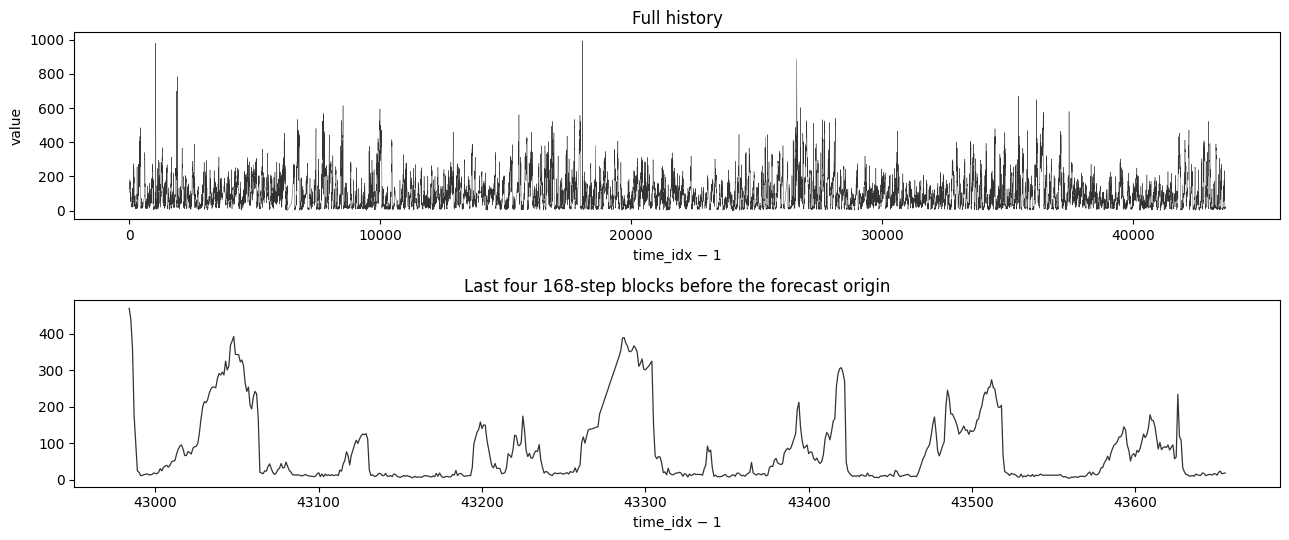

In [25]:
s = pd.Series(y_raw)
print(s.describe(percentiles=[.01, .25, .5, .75, .9, .99]).round(1).to_string())
print(f"skewness = {s.skew():.2f};  exact zeros = {(y_raw == 0).sum()}")

fig, ax = plt.subplots(2, 1, figsize=(13, 5.5))
ax[0].plot(y_raw, lw=0.3, color="#333"); ax[0].set(title="Full history", xlabel="time_idx − 1", ylabel="value")
ax[1].plot(np.arange(N - 4 * H, N), y_raw[-4 * H:], lw=0.9, color="#333")
ax[1].set(title="Last four 168-step blocks before the forecast origin", xlabel="time_idx − 1")
plt.tight_layout(); save_fig("series_overview")

autocorrelation at selected lags: {1: 0.966, 6: 0.749, 12: 0.57, 24: 0.401, 48: 0.158, 72: 0.077, 168: 0.028, 336: 0.048}
periodogram peak in 8–60 steps: 24;  ACF-of-differences peak: 24
largest periodogram peaks overall (period in steps): [269.5 183.4 386.3  24.  338.4 379.6]


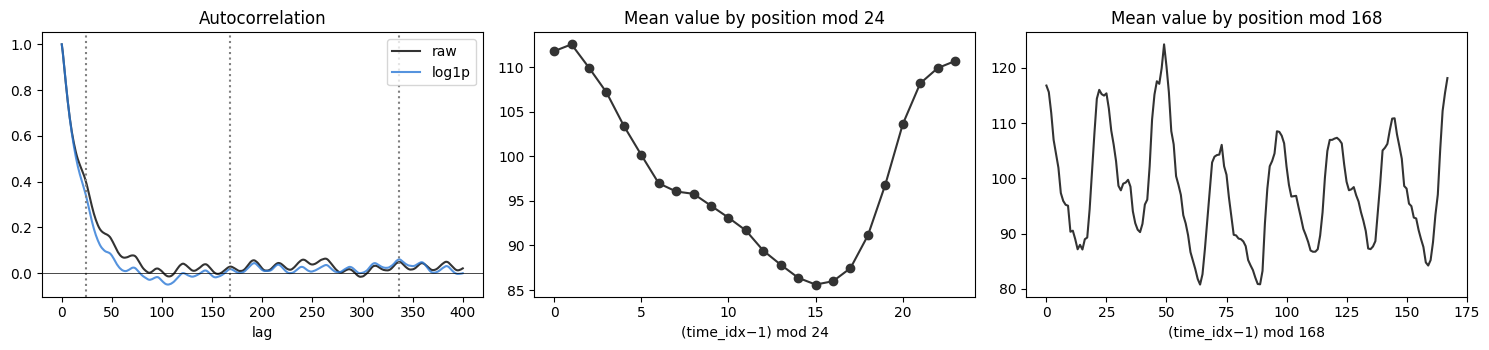

In [26]:
def acf(x, max_lag):
    x = np.asarray(x, float) - np.mean(x)
    spec = np.fft.rfft(x, n=2 * len(x))
    full = np.fft.irfft(spec * np.conj(spec))[: max_lag + 1]
    return full / full[0]

MAX_LAG = 400
r_raw, r_log = acf(y_raw, MAX_LAG), acf(np.log1p(y_raw), MAX_LAG)
print("autocorrelation at selected lags:",
      {k: round(float(r_raw[k]), 3) for k in (1, 6, 12, 24, 48, 72, 168, 336)})
# The raw ACF decays monotonically at short lags (strong persistence), so its maximum on a lag
# range is just the smallest lag. Recover the period two other ways instead:
#   (1) periodogram of log1p(value), peak among periods 8–60 steps;
#   (2) ACF of first differences (removes persistence), peak among lags 8–60.
z = np.log1p(y_raw) - np.log1p(y_raw).mean()
power = np.abs(np.fft.rfft(z)) ** 2
freqs = np.fft.rfftfreq(len(z))
band = (freqs >= 1 / 60) & (freqs <= 1 / 8)
PERIOD = int(round(1 / freqs[band][np.argmax(power[band])]))
r_diff = acf(np.diff(z), 100)
lags = np.arange(8, 61)
period_acf = int(lags[np.argmax(r_diff[lags])])
print(f"periodogram peak in 8–60 steps: {PERIOD};  ACF-of-differences peak: {period_acf}")
assert PERIOD == period_acf, "the two period estimates disagree: inspect the plots before continuing"
wide = (freqs > 1 / 400) & (freqs < 1 / 4)
top = np.argsort(power[wide])[::-1][:6]
print("largest periodogram peaks overall (period in steps):", np.round(1 / freqs[wide][top], 1))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].plot(r_raw, label="raw", color="#333"); ax[0].plot(r_log, label="log1p", color="#2a78d6", alpha=.8)
for k in (24, 168, 336): ax[0].axvline(k, ls=":", color="grey")
ax[0].axhline(0, color="k", lw=.5); ax[0].set(title="Autocorrelation", xlabel="lag"); ax[0].legend()
prof24 = s.groupby(np.arange(N) % PERIOD).mean()
ax[1].plot(prof24.index, prof24.values, marker="o", color="#333")
ax[1].set(title=f"Mean value by position mod {PERIOD}", xlabel=f"(time_idx−1) mod {PERIOD}")
prof168 = s.groupby(np.arange(N) % 168).mean()
ax[2].plot(prof168.index, prof168.values, color="#333"); ax[2].set(title="Mean value by position mod 168", xlabel="(time_idx−1) mod 168")
plt.tight_layout(); save_fig("memory_and_period")

,corr with value,corr with log1p(value),x(t-24) vs y(t),x(t-6) vs y(t),x(t+0) vs y(t),x(t+6) vs y(t),x(t+24) vs y(t)
feature_A,0.169,0.308,0.101,0.244,0.309,0.283,0.193
feature_B,-0.088,0.019,0.002,0.049,0.019,0.058,0.044
feature_C,-0.048,-0.159,0.023,-0.128,-0.158,-0.172,-0.100
feature_D,-0.245,-0.348,-0.153,-0.302,-0.348,-0.308,-0.124
feature_E,0.019,0.032,-0.018,0.035,0.032,0.029,0.035
feature_F,-0.050,-0.049,-0.071,-0.069,-0.049,0.001,0.063
feature_G,-0.033,-0.064,-0.021,-0.070,-0.064,-0.033,0.017
feature_H,-0.212,-0.346,-0.215,-0.432,-0.346,-0.190,-0.060
feature_I,0.097,0.226,0.140,0.312,0.225,0.119,0.022
feature_J,0.154,0.182,0.099,0.183,0.182,0.104,0.029


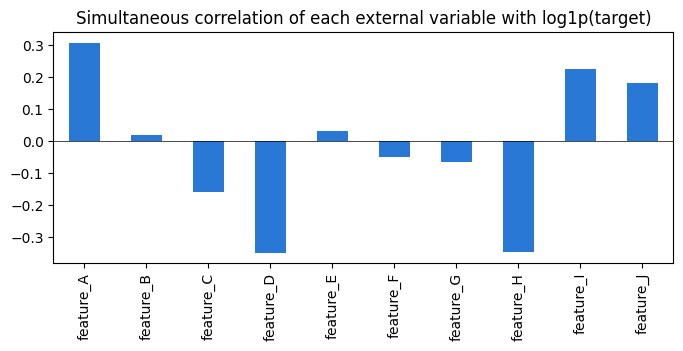

In [27]:
CONT = ["feature_A", "feature_B", "feature_C", "feature_D", "feature_E", "feature_F"]
BIN = ["feature_G", "feature_H", "feature_I", "feature_J"]
EXT = CONT + BIN
assert (ext_df[BIN].sum(axis=1) == 1).all(), "binary indicators should be mutually exclusive"
hist = ext_df.iloc[:N]
corr = pd.DataFrame({
    "corr with value": [np.corrcoef(hist[c], y_raw)[0, 1] for c in EXT],
    "corr with log1p(value)": [np.corrcoef(hist[c], np.log1p(y_raw))[0, 1] for c in EXT],
}, index=EXT)
# lead/lag check: correlation of the variable at time t+k with log1p(target) at time t
for k in (-24, -6, 0, 6, 24):
    corr[f"x(t{k:+d}) vs y(t)"] = [np.corrcoef(np.roll(hist[c].values, -k)[48:-48], np.log1p(y_raw)[48:-48])[0, 1] for c in EXT]
display(corr.round(3))
corr.round(4).to_csv(OUT / "external_correlations.csv")

corr["corr with log1p(value)"].plot.bar(figsize=(8, 3), color="#2a78d6")
plt.axhline(0, color="k", lw=.5); plt.title("Simultaneous correlation of each external variable with log1p(target)")
save_fig("external_correlations")

## 2. Validation protocol and baselines

The leaderboard scores **one** 168-step block, which is a noisy sample, and we only get five
submissions. Every decision here is therefore made on a **chronological rolling-origin**
estimate built from many blocks:

```
|──────────────── train ────────────────|──── evaluation: 26 non-overlapping 168-step blocks ────|
0                                   eval_start                                                 N
```

* **train**: fits weights and all preprocessing statistics (scalers).
* **evaluation**: 26 blocks (about half a year). Configurations **and the number of training
  epochs** are chosen here, always as the mean over blocks and over seeds, with block-level
  paired differences.

Why no separate early-stopping split? A first check showed that an 8-week early-stopping
window disagreed with the 26-block evaluation about when to stop, because 8 weeks is too
noisy. The number of epochs is therefore treated as a hyper-parameter: every run records its
evaluation RMSE after each epoch, and the epoch count with the best mean over seeds is used,
fixed, for the final fit on all data.

**Naive baselines** show how much of the 168-step horizon the target's own past can explain.

In [28]:
N_EVAL_BLOCKS = 26
EVAL_START = N - N_EVAL_BLOCKS * H
EVAL_ORIGINS = EVAL_START + H * np.arange(N_EVAL_BLOCKS)       # 0-based index of first forecast step
print(f"train targets [0, {EVAL_START}) · evaluation blocks [{EVAL_START}, {N})")

def smape(y, p):
    den = np.abs(y) + np.abs(p)
    return 100 * np.mean(np.where(den == 0, 0.0, 2 * np.abs(p - y) / np.where(den == 0, 1, den)))

def block_metrics(pred, origins, tag):
    rows = []
    for b, o in enumerate(origins):
        yt, pt = y_raw[o:o + H], pred[b]
        rows.append({**tag, "block": b, "RMSE": float(np.sqrt(np.mean((pt - yt) ** 2))),
                     "MAE": float(np.mean(np.abs(pt - yt))), "sMAPE": smape(yt, pt)})
    return rows

def baseline_forecasts(origins):
    out = {}
    out["persistence (last value)"] = np.stack([np.full(H, y_raw[o - 1]) for o in origins])
    out[f"seasonal naive ({PERIOD})"] = np.stack([np.resize(y_raw[o - PERIOD:o], H) for o in origins])
    out["seasonal naive (168)"] = np.stack([y_raw[o - H:o] for o in origins])
    out["mean of last 168"] = np.stack([np.full(H, y_raw[o - H:o].mean()) for o in origins])
    out["mean of last 24"] = np.stack([np.full(H, y_raw[o - 24:o].mean()) for o in origins])
    return out

BASE_PRED = baseline_forecasts(EVAL_ORIGINS)
base_rows = []
for name, p in BASE_PRED.items():
    base_rows += block_metrics(p, EVAL_ORIGINS, {"model": name})
baselines = pd.DataFrame(base_rows).groupby("model")[["RMSE", "MAE", "sMAPE"]].agg(["mean", "std"])
display(baselines.round(2))
baselines.round(3).to_csv(OUT / "baselines.csv")
BEST_BASELINE = baselines[("RMSE", "mean")].idxmin()
BEST_BASELINE_RMSE = baselines[("RMSE", "mean")].min()
print(f"best naive baseline on the evaluation blocks: {BEST_BASELINE} (RMSE {BEST_BASELINE_RMSE:.2f})")

train targets [0, 39288) · evaluation blocks [39288, 43656)


RMSE           MAE         sMAPE       
                            mean    std   mean    std   mean    std
model                                                              
mean of last 168           82.80  37.08  68.21  31.50  79.48  21.48
mean of last 24            96.95  55.54  78.58  47.63  88.04  23.51
persistence (last value)  115.35  92.10  95.54  87.35  88.31  24.29
seasonal naive (168)      113.06  52.23  89.69  42.10  97.31  21.51
seasonal naive (24)       106.63  58.26  84.52  49.27  94.22  22.78

best naive baseline on the evaluation blocks: mean of last 168 (RMSE 82.80)


## 3. Preprocessing and feature engineering

**Target.** Two options, compared in Experiment 1:
* `log1p`: compresses the heavy right tail and stabilises training. Back-transforming the mean
  of log values gives a median-like forecast, which can under-predict the mean and hurt RMSE.
* `none`: standardised raw values. This matches the RMSE objective directly, but the spikes
  dominate the gradient.

In both cases the transformed target is standardised with the **train-region** mean and std.
Forecasts are mapped back and clipped at 0, since the target is non-negative.

**External variables** (all 43,824 rows; the last 168 are known over the horizon):
* continuous A–F: D, E and F are non-negative and highly skewed, so they get `log1p`. All six
  are then standardised with train-region statistics.
* binary G–J (one-hot, mutually exclusive): used as they are.

**Phase features.** sin/cos of 2π·t/PERIOD and 2π·t/168, derived only from `time_idx` and the
recovered period. They stand in for the missing calendar features and are known for every
future step. They are kept the same in all external-data variants, so that ablation isolates
the external file.

**Where external data enters (the `external` switch):**

| mode | encoder covariates (past window) | decoder covariates (label part + 168 future steps) |
|---|---|---|
| `none` | phase | phase |
| `past` | phase + external (past only) | phase |
| `full` | phase + external (past) | phase + external (**including the known future**) |
| `full+roll` | as `full`, plus trailing 6/24/72-step means of every variable | as `full`, plus the same trailing means |

In [29]:
ROLL_WINDOWS = (6, 24, 72)

def build_covariates(train_end, use_phase=True, rolling=False):
    """Phase and external covariate arrays for all T_ALL steps; statistics from [0, train_end).
    Column layout of the external block: the 10 variables, then (if rolling) the 10 trailing
    means for each window in ROLL_WINDOWS, so variable j sits at columns j, j+10, j+20, ..."""
    ext = ext_df[EXT].astype(float).copy()
    for c in ("feature_D", "feature_E", "feature_F"):
        ext[c] = np.log1p(ext[c].clip(lower=0))
    blocks = [ext]
    if rolling:   # trailing means use only values at or before t; the file covers the horizon too
        for w in ROLL_WINDOWS:
            blocks.append(ext.rolling(w, min_periods=1).mean().add_suffix(f"_mean{w}"))
    ext = pd.concat(blocks, axis=1)
    binary = [c for c in ext.columns if c in BIN]            # raw one-hot columns stay 0/1
    scale = [c for c in ext.columns if c not in binary]
    mu, sd = ext.iloc[:train_end][scale].mean(), ext.iloc[:train_end][scale].std().replace(0, 1)
    ext[scale] = (ext[scale] - mu) / sd
    t = np.arange(T_ALL, dtype=float)
    phase = np.stack([f(2 * np.pi * t / p) for p in (PERIOD, 168) for f in (np.sin, np.cos)], 1)
    if not use_phase:
        phase = phase[:, :0]
    fill = ext.iloc[:train_end].mean().to_numpy()   # neutral values used by the occlusion study
    return phase.astype(np.float32), ext.to_numpy(np.float32), fill.astype(np.float32)

class TargetScaler:
    def __init__(self, kind, train_end):
        self.kind = kind
        z = self._fwd(y_raw[:train_end])
        self.mu, self.sd = float(z.mean()), float(z.std())
    def _fwd(self, y):
        return np.log1p(y) if self.kind == "log1p" else np.asarray(y, float)
    def transform(self, y):
        return (self._fwd(y) - self.mu) / self.sd
    def inverse(self, z):
        v = np.asarray(z, float) * self.sd + self.mu
        v = np.expm1(v) if self.kind == "log1p" else v
        return np.clip(v, 0, None)

class Batcher:
    """Builds (x_enc, mark_enc, mark_dec, target) batches by indexing GPU-resident arrays."""
    def __init__(self, cfg, train_end):
        self.cfg = cfg
        self.scaler = TargetScaler(cfg["target_transform"], train_end)
        y_full = np.zeros(T_ALL, np.float32)
        y_full[:N] = self.scaler.transform(y_raw)          # unknown future stays 0 and is never an input
        phase, ext, fill = build_covariates(train_end, cfg["use_phase"], cfg["rolling"])
        mode = cfg["external"]
        enc = [phase] + ([ext] if mode in ("past", "full") else [])
        dec = [phase] + ([ext] if mode == "full" else [])
        self.n_phase, self.n_ext = phase.shape[1], ext.shape[1]
        self.enc_uses_ext, self.dec_uses_ext = mode in ("past", "full"), mode == "full"
        to = lambda a: torch.tensor(a, device=DEVICE)
        self.y = to(y_full)
        self.m_enc = to(np.concatenate(enc, 1))
        self.m_dec = to(np.concatenate(dec, 1))
        self.fill = to(fill)
        L, lab, P = cfg["seq_len"], cfg["label_len"], cfg["pred_len"]
        self.r_enc = torch.arange(-L, 0, device=DEVICE)
        self.r_dec = torch.arange(-lab, P, device=DEVICE)
        self.r_tgt = torch.arange(0, P, device=DEVICE)

    def get(self, origins, occlude=None):
        o = torch.as_tensor(np.asarray(origins), device=DEVICE).long()[:, None]
        ie, idd = o + self.r_enc, o + self.r_dec
        x_enc = self.y[ie].unsqueeze(-1)
        m_enc, m_dec = self.m_enc[ie], self.m_dec[idd]
        if occlude is not None:                    # replace chosen external columns by train means
            m_enc, m_dec = m_enc.clone(), m_dec.clone()
            variables, part = occlude
            cols = [j + len(EXT) * k for j in variables for k in range(self.n_ext // len(EXT))]
            for c in cols:
                v = self.fill[c]
                if self.enc_uses_ext and part in ("all", "past"):
                    m_enc[..., self.n_phase + c] = v
                if self.dec_uses_ext:
                    lab = self.cfg["label_len"]
                    if part in ("all", "past"):
                        m_dec[:, :lab, self.n_phase + c] = v
                    if part in ("all", "future"):
                        m_dec[:, lab:, self.n_phase + c] = v
        target = self.y[o + self.r_tgt]
        return x_enc, m_enc, m_dec, target

## 4. The Autoformer

```
x_enc ─► decomp ─► seasonal_init (last label_len + zeros)  ─► dec-embedding ─┐
  │           └──► trend_init   (last label_len + mean(x_enc)) ──────────────┼─► trend accumulation
  └─► enc-embedding ─► [Encoder: Auto-Correlation → decomp → FFN → decomp] ─► cross ─► [Decoder:
       self Auto-Correlation → decomp → cross Auto-Correlation → decomp → FFN → decomp;
       each decomp's trend is projected and added to the trend] ─► seasonal + trend ─► 168 forecasts
```

* **Series decomposition** (Eq. 1 of the paper): replicate-padded centred moving average. It is
  applied to the input and **after every sub-layer** of every encoder and decoder layer
  (progressive decomposition). The decoder accumulates the extracted trends.
* **Auto-Correlation** (Eqs. 5–6): R(τ) = Σ_t q_t k_{(t−τ) mod L} for all τ at once via FFT,
  averaged over heads and channels. Keep the top k = ⌊factor·ln L⌋ delays, softmax their scores,
  and aggregate `v[(t − τ_j) mod L]` with those weights.
* **Embeddings**: a value embedding (circular Conv1d, kernel 3), plus a linear embedding of the
  covariates standing in for the paper's timestamp embedding. There is no positional encoding,
  as in the paper.

In [30]:
class SeriesDecomp(nn.Module):
    def __init__(self, kernel):
        super().__init__()
        assert kernel % 2 == 1, "moving-average width must be odd"
        self.kernel = kernel
    def forward(self, x):                                     # x [B, L, C]
        r = self.kernel // 2
        if r == 0:
            return x - x, x
        padded = torch.cat([x[:, :1].expand(-1, r, -1), x, x[:, -1:].expand(-1, r, -1)], 1)
        trend = F.avg_pool1d(padded.transpose(1, 2), self.kernel, stride=1).transpose(1, 2)
        return x - trend, trend                               # (seasonal, trend)

class SeasonalLayerNorm(nn.Module):
    """Autoformer's my_Layernorm: LayerNorm, then remove the per-series mean over time."""
    def __init__(self, d):
        super().__init__(); self.norm = nn.LayerNorm(d)
    def forward(self, x):
        x = self.norm(x)
        return x - x.mean(1, keepdim=True)

def delay_scores(q, k):
    """q, k: [B, heads, E, L] -> R(tau) averaged over heads and E: [B, L]."""
    L = q.shape[-1]
    spec = torch.fft.rfft(q.float(), dim=-1) * torch.conj(torch.fft.rfft(k.float(), dim=-1))
    return torch.fft.irfft(spec, n=L, dim=-1).mean((1, 2))

def aggregate_delays(v, delays, weights):
    """v: [B, heads, D, L]; delays, weights: [B, K] -> sum_j w_j * v[(t - tau_j) mod L]."""
    B, h, D, L = v.shape
    K = delays.shape[1]
    t = torch.arange(L, device=v.device)
    idx = (t.view(1, 1, L) - delays.view(B, K, 1)) % L
    idx = idx.view(B, K, 1, 1, L).expand(-1, -1, h, D, -1)
    shifted = torch.gather(v.unsqueeze(1).expand(-1, K, -1, -1, -1), -1, idx)
    return (weights.view(B, K, 1, 1, 1) * shifted).sum(1)

class AutoCorrelation(nn.Module):
    def __init__(self, factor=1):
        super().__init__(); self.factor = factor
        self.last_delays = None
    def forward(self, q, k, v):                               # [B, L, h, E], [B, S, h, E], [B, S, h, D]
        B, L, h, E = q.shape
        S = k.shape[1]
        if L > S:                                             # align key/value length to query length
            pad = torch.zeros_like(q[:, : L - S])
            k = torch.cat([k, pad], 1); v = torch.cat([v, pad[..., : v.shape[-1]]], 1)
        else:
            k, v = k[:, :L], v[:, :L]
        scores = delay_scores(q.permute(0, 2, 3, 1), k.permute(0, 2, 3, 1))   # [B, L]
        top_k = max(1, int(self.factor * math.log(L)))
        w, delays = torch.topk(scores, top_k, dim=-1)                          # per example
        self.last_delays = delays.detach()
        w = torch.softmax(w, dim=-1).to(v.dtype)
        out = aggregate_delays(v.permute(0, 2, 3, 1), delays, w)               # [B, h, D, L]
        return out.permute(0, 3, 1, 2)                                         # [B, L, h, D]

class AutoCorrelationLayer(nn.Module):
    def __init__(self, d_model, n_heads, factor):
        super().__init__()
        self.h = n_heads
        self.q, self.k, self.v, self.o = (nn.Linear(d_model, d_model) for _ in range(4))
        self.inner = AutoCorrelation(factor)
    def forward(self, xq, xk, xv):
        B, L, d = xq.shape; S = xk.shape[1]
        q = self.q(xq).view(B, L, self.h, -1)
        k = self.k(xk).view(B, S, self.h, -1)
        v = self.v(xv).view(B, S, self.h, -1)
        return self.o(self.inner(q, k, v).reshape(B, L, d))

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.c1 = nn.Conv1d(d_model, d_ff, 1, bias=False)
        self.c2 = nn.Conv1d(d_ff, d_model, 1, bias=False)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        y = self.drop(F.gelu(self.c1(x.transpose(1, 2))))
        return self.drop(self.c2(y).transpose(1, 2))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, kernel, factor, dropout):
        super().__init__()
        self.attn = AutoCorrelationLayer(d_model, n_heads, factor)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.d1, self.d2 = SeriesDecomp(kernel), SeriesDecomp(kernel)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        x, _ = self.d1(x + self.drop(self.attn(x, x, x)))
        x, _ = self.d2(x + self.ff(x))
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, kernel, factor, dropout, c_out):
        super().__init__()
        self.self_attn = AutoCorrelationLayer(d_model, n_heads, factor)
        self.cross_attn = AutoCorrelationLayer(d_model, n_heads, factor)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.d1, self.d2, self.d3 = SeriesDecomp(kernel), SeriesDecomp(kernel), SeriesDecomp(kernel)
        self.drop = nn.Dropout(dropout)
        self.trend_proj = nn.Conv1d(d_model, c_out, 3, padding=1, padding_mode="circular", bias=False)
    def forward(self, x, cross):
        x, t1 = self.d1(x + self.drop(self.self_attn(x, x, x)))
        x, t2 = self.d2(x + self.drop(self.cross_attn(x, cross, cross)))
        x, t3 = self.d3(x + self.ff(x))
        trend = self.trend_proj((t1 + t2 + t3).transpose(1, 2)).transpose(1, 2)
        return x, trend

class Embedding(nn.Module):
    def __init__(self, c_in, mark_dim, d_model, dropout):
        super().__init__()
        self.value = nn.Conv1d(c_in, d_model, 3, padding=1, padding_mode="circular", bias=False)
        self.mark = nn.Linear(mark_dim, d_model, bias=False) if mark_dim > 0 else None
        self.drop = nn.Dropout(dropout)
    def forward(self, x, mark):
        e = self.value(x.transpose(1, 2)).transpose(1, 2)
        if self.mark is not None:
            e = e + self.mark(mark)
        return self.drop(e)

class Autoformer(nn.Module):
    def __init__(self, cfg, enc_mark_dim, dec_mark_dim, c_in=1, c_out=1):
        super().__init__()
        self.cfg = cfg
        d, h, ff, k, fac, dr = (cfg[x] for x in ("d_model", "n_heads", "d_ff", "moving_avg", "factor", "dropout"))
        self.decomp = SeriesDecomp(k)
        self.enc_emb = Embedding(c_in, enc_mark_dim, d, dr)
        self.dec_emb = Embedding(c_in, dec_mark_dim, d, dr)
        self.encoder = nn.ModuleList([EncoderLayer(d, h, ff, k, fac, dr) for _ in range(cfg["e_layers"])])
        self.enc_norm = SeasonalLayerNorm(d)
        self.decoder = nn.ModuleList([DecoderLayer(d, h, ff, k, fac, dr, c_out) for _ in range(cfg["d_layers"])])
        self.dec_norm = SeasonalLayerNorm(d)
        self.proj = nn.Linear(d, c_out)

    def forward(self, x_enc, mark_enc, mark_dec):
        lab, P = self.cfg["label_len"], self.cfg["pred_len"]
        mean = x_enc.mean(1, keepdim=True).expand(-1, P, -1)
        zeros = torch.zeros_like(mean)
        seasonal_init, trend_init = self.decomp(x_enc)
        trend = torch.cat([trend_init[:, -lab:], mean], 1)
        seasonal = torch.cat([seasonal_init[:, -lab:], zeros], 1)
        enc = self.enc_emb(x_enc, mark_enc)
        for layer in self.encoder:
            enc = layer(enc)
        enc = self.enc_norm(enc)
        dec = self.dec_emb(seasonal, mark_dec)
        for layer in self.decoder:
            dec, t = layer(dec, enc)
            trend = trend + t
        out = self.proj(self.dec_norm(dec)) + trend
        return out[:, -P:, 0]                                  # [B, P]

def n_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### Unit checks
These use the Task 1 worked examples, plus shape and gradient tests.

In [31]:
_ex = torch.tensor([1., 2., 3., 10., 5.]).view(1, 5, 1)
_s, _t = SeriesDecomp(3)(_ex)
assert torch.allclose(_t.flatten(), torch.tensor([4 / 3, 2., 5., 6., 20 / 3])) and torch.allclose(_s + _t, _ex)
_q = torch.tensor([1., 3., 1., 3.]).view(1, 1, 1, 4)
assert torch.allclose(delay_scores(_q - 2, _q - 2).flatten(), torch.tensor([4., -4., 4., -4.]))
_agg = aggregate_delays(torch.tensor([10., 20., 30., 40.]).view(1, 1, 1, 4), torch.tensor([[1, 3]]), torch.tensor([[.75, .25]]))
assert torch.allclose(_agg.flatten(), torch.tensor([35., 15., 25., 25.])), "delay direction is wrong"
_cfg = dict(seq_len=48, label_len=24, pred_len=24, d_model=8, n_heads=2, d_ff=16, moving_avg=5,
            factor=1, dropout=0.0, e_layers=1, d_layers=1)
_m = Autoformer(_cfg, 3, 3)
_x = torch.randn(2, 48, 1, requires_grad=True)
_o = _m(_x, torch.randn(2, 48, 3), torch.randn(2, 48, 3))
assert _o.shape == (2, 24)
_o.sum().backward(); assert _x.grad is not None and torch.isfinite(_x.grad).all()
print("decomposition, delay-score, aggregation, shape and gradient checks passed")

decomposition, delay-score, aggregation, shape and gradient checks passed


## 5. Training and evaluation utilities

* **Loss**: MSE on the transformed, standardised target, averaged over all 168 steps. This is
  direct multi-step forecasting, so predictions are never fed back as inputs.
* **Optimiser**: Adam, learning rate multiplied by `lr_decay` after every epoch, gradient
  clipping at 1.0.
* **Training windows**: every `train_stride`-th forecast origin whose 168-step target lies
  entirely in the training region. Neighbouring windows overlap almost completely, so stride 4
  loses little information and gives short epochs, which makes the epoch count a fine-grained
  control.
* **Epoch selection**: after every epoch, the model forecasts the 26 evaluation blocks. The
  epoch count with the lowest RMSE (mean over seeds) is chosen per configuration. The final
  model is trained for exactly that many epochs, and E counts them all.

In [32]:
BASE_CFG = dict(
    seq_len=336, label_len=168, pred_len=H,
    d_model=32, n_heads=4, d_ff=64, e_layers=1, d_layers=1,
    moving_avg=PERIOD + 1 if PERIOD % 2 == 0 else PERIOD, factor=1, dropout=0.1,
    batch_size=128, lr=3e-4, lr_decay=0.85, max_epochs=25, train_stride=4, clip=1.0,
    target_transform="log1p", external="full", rolling=False, use_phase=True,
)
if QUICK:
    BASE_CFG.update(train_stride=32, max_epochs=3)
    SEEDS = SEEDS[:2]
    FINAL_SEEDS = FINAL_SEEDS[:2]
print(json.dumps(BASE_CFG, indent=1))

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

@torch.no_grad()
def predict(model, batcher, origins, occlude=None, bs=256):
    model.eval()
    out = []
    for i in range(0, len(origins), bs):
        x, me, md, _ = batcher.get(origins[i:i + bs], occlude)
        out.append(model(x, me, md).float().cpu().numpy())
    return batcher.scaler.inverse(np.concatenate(out))        # original units, clipped at 0

def raw_rmse(pred, origins):
    tgt = np.stack([y_raw[o:o + H] for o in origins])
    return float(np.sqrt(np.mean((pred - tgt) ** 2)))

def train_model(cfg, seed, train_end, n_epochs, track=None, verbose=True, keep_states=True):
    """Train for n_epochs on targets inside [0, train_end). If `track` (origins) is given,
    forecast them after every epoch and keep those forecasts plus a weight snapshot."""
    set_seed(seed)
    batcher = Batcher(cfg, train_end)                          # scalers see the training region only
    tr_orig = np.arange(cfg["seq_len"], train_end - H + 1, cfg["train_stride"])
    model = Autoformer(cfg, batcher.m_enc.shape[1], batcher.m_dec.shape[1]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    rng = np.random.default_rng(seed)
    history, preds, states = [], [], []
    t0 = time.time()
    for epoch in range(n_epochs):
        for g in opt.param_groups:
            g["lr"] = cfg["lr"] * cfg["lr_decay"] ** epoch
        model.train()
        perm = rng.permutation(tr_orig)
        losses = []
        for i in range(0, len(perm), cfg["batch_size"]):
            x, me, md, y = batcher.get(perm[i:i + cfg["batch_size"]])
            loss = F.mse_loss(model(x, me, md), y)
            opt.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg["clip"]); opt.step()
            losses.append(loss.item())
        rec = {"epoch": epoch + 1, "train_loss": float(np.mean(losses))}
        if track is not None:
            p = predict(model, batcher, track)
            preds.append(p); rec["eval_RMSE"] = raw_rmse(p, track)
            if keep_states:
                states.append({k: v.detach().cpu().clone() for k, v in model.state_dict().items()})
        history.append(rec)
        if verbose:
            print(f"    epoch {epoch + 1:2d}  train MSE {rec['train_loss']:.4f}"
                  + (f"  eval RMSE {rec['eval_RMSE']:8.3f}" if track is not None else ""))
    info = {"epochs_run": n_epochs, "params": n_params(model), "seconds": time.time() - t0,
            "history": history, "preds": preds, "states": states}
    return model, batcher, info

{
 "seq_len": 336,
 "label_len": 168,
 "pred_len": 168,
 "d_model": 32,
 "n_heads": 4,
 "d_ff": 64,
 "e_layers": 1,
 "d_layers": 1,
 "moving_avg": 25,
 "factor": 1,
 "dropout": 0.1,
 "batch_size": 128,
 "lr": 0.0003,
 "lr_decay": 0.85,
 "max_epochs": 25,
 "train_stride": 4,
 "clip": 1.0,
 "target_transform": "log1p",
 "external": "full",
 "rolling": false,
 "use_phase": true
}


## 6. Why the leaderboard week is harder than the validation average

Each of the 26 validation weeks is summarised by the target's mean, spread and maximum, plus
the RMSE of the best naive baseline. The last 12 weeks are a different regime: higher level,
2–3× the spread, and spikes of 400–520. The leaderboard week directly follows them. An
average over all 26 weeks is dominated by the calm early weeks, which is why v1's validation
RMSE (~55–59) was far below its leaderboard RMSE (99).

,block,mean,std,max,baseline RMSE,regime
0,0,63.8,45.1,199.0,45.1,early
1,1,141.2,79.7,303.0,111.0,early
2,2,41.3,34.9,172.0,105.9,early
3,3,64.2,49.8,220.0,54.8,early
4,4,96.4,37.4,212.0,49.3,early
5,5,86.0,62.5,250.0,63.4,early
6,6,44.9,31.2,160.0,51.5,early
7,7,58.2,31.5,209.0,34.2,early
8,8,58.5,49.2,173.0,49.2,early
9,9,80.3,49.5,196.0,54.1,early


                     mean    std    max  baseline RMSE
regime                                                
early                73.2   46.2  206.9           58.1
recent (decisions)  109.2  101.2  387.8          111.6


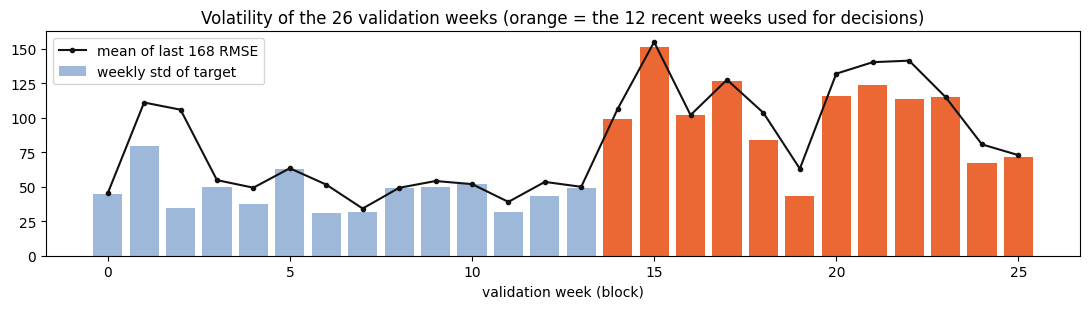

In [33]:
N_RECENT = 12
RECENT = np.arange(N_EVAL_BLOCKS - N_RECENT, N_EVAL_BLOCKS)
TRUTH = np.stack([y_raw[o:o + H] for o in EVAL_ORIGINS])                 # [26, H]
blk = pd.DataFrame({"block": np.arange(N_EVAL_BLOCKS), "mean": TRUTH.mean(1), "std": TRUTH.std(1),
                    "max": TRUTH.max(1),
                    "baseline RMSE": np.sqrt(((BASE_PRED[BEST_BASELINE] - TRUTH) ** 2).mean(1))})
blk["regime"] = np.where(blk.block.isin(RECENT), "recent (decisions)", "early")
display(blk.round(1))
print(blk.groupby("regime")[["mean", "std", "max", "baseline RMSE"]].mean().round(1))
blk.round(3).to_csv(OUT / "block_volatility.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.bar(blk.block, blk["std"], color=np.where(blk.block.isin(RECENT), "#eb6834", "#9db8d9"), label="weekly std of target")
ax.plot(blk.block, blk["baseline RMSE"], color="#111", marker="o", ms=3, label=f"{BEST_BASELINE} RMSE")
ax.set(xlabel="validation week (block)", title="Volatility of the 26 validation weeks (orange = the 12 recent weeks used for decisions)")
ax.legend(); plt.tight_layout(); save_fig("block_volatility")

def block_rmse(pred):                         # pred [26, H] -> per-week RMSE [26]
    return np.sqrt(((pred - TRUTH) ** 2).mean(1))

def score(pred, blocks):                      # mean weekly RMSE over the chosen weeks
    return float(block_rmse(pred)[blocks].mean())

## 7. Candidate models: 5 seeds each, up to 25 epochs

Three candidates, all with future covariates and trailing means (`full+roll`), which were
clearly best in v1's ablation:

* `log1p|d32`: v1's model (epochs 1–15 reproduce v1's training schedule exactly);
* `log1p|d64`: wider model (v1's size sweep: better seed stability);
* `none|d32`: raw-scale target. Its MSE loss matches the RMSE metric, so its peaks are less
  damped, which is a natural partner for blending.

Every run forecasts all 26 validation weeks after every epoch.

In [34]:
V2_SEEDS = [0, 1, 2, 3, 4] if not QUICK else [0, 1]
CANDS = {
    "log1p|d32": dict(BASE_CFG, target_transform="log1p", external="full", rolling=True),
    "log1p|d64": dict(BASE_CFG, target_transform="log1p", external="full", rolling=True, d_model=64, d_ff=128),
    "none|d32": dict(BASE_CFG, target_transform="none", external="full", rolling=True),
}
PRED, PARAMS = {}, {}
for name, cfg in CANDS.items():
    runs = []
    for seed in V2_SEEDS:
        _, _, info = train_model(cfg, seed, EVAL_START, cfg["max_epochs"], track=EVAL_ORIGINS,
                                 verbose=False, keep_states=False)
        runs.append(np.stack(info["preds"]))                             # [epochs, 26, H]
        PARAMS[name] = info["params"]
        best = min(info["history"], key=lambda r: r["eval_RMSE"])
        print(f"[{name}] seed {seed}: {info['seconds']:.0f}s; best pooled eval RMSE {best['eval_RMSE']:.2f} at epoch {best['epoch']}")
    PRED[name] = np.stack(runs)                                          # [seeds, epochs, 26, H]
np.savez_compressed(OUT / "validation_predictions.npz", **{k.replace("|", "_"): v for k, v in PRED.items()})

[log1p|d32] seed 0: 63s; best pooled eval RMSE 62.53 at epoch 25
[log1p|d32] seed 1: 61s; best pooled eval RMSE 62.69 at epoch 23
[log1p|d32] seed 2: 61s; best pooled eval RMSE 60.41 at epoch 10
[log1p|d32] seed 3: 61s; best pooled eval RMSE 63.31 at epoch 15
[log1p|d32] seed 4: 61s; best pooled eval RMSE 63.68 at epoch 17
[log1p|d64] seed 0: 119s; best pooled eval RMSE 64.19 at epoch 8
[log1p|d64] seed 1: 119s; best pooled eval RMSE 63.79 at epoch 19
[log1p|d64] seed 2: 119s; best pooled eval RMSE 62.22 at epoch 14
[log1p|d64] seed 3: 119s; best pooled eval RMSE 59.23 at epoch 7
[log1p|d64] seed 4: 119s; best pooled eval RMSE 62.89 at epoch 7
[none|d32] seed 0: 61s; best pooled eval RMSE 62.80 at epoch 24
[none|d32] seed 1: 61s; best pooled eval RMSE 66.98 at epoch 3
[none|d32] seed 2: 61s; best pooled eval RMSE 65.47 at epoch 3
[none|d32] seed 3: 61s; best pooled eval RMSE 63.20 at epoch 6
[none|d32] seed 4: 61s; best pooled eval RMSE 65.72 at epoch 3


### Epoch curves (seed-ensemble)

For every candidate and epoch, average the seeds' forecasts (the ensemble we would submit)
and score it on the recent 12 weeks and on all 26. The epoch for each candidate is chosen on
the **recent** weeks, among epochs ≥ 3.

,epoch,recent RMSE,all-26 RMSE,single-seed recent RMSE,params (one model)
candidate,,,,,
log1p|d32,21,65.63,53.45,71.20,24129
log1p|d64,21,64.13,52.44,72.96,89217
none|d32,4,77.63,59.51,80.14,24129


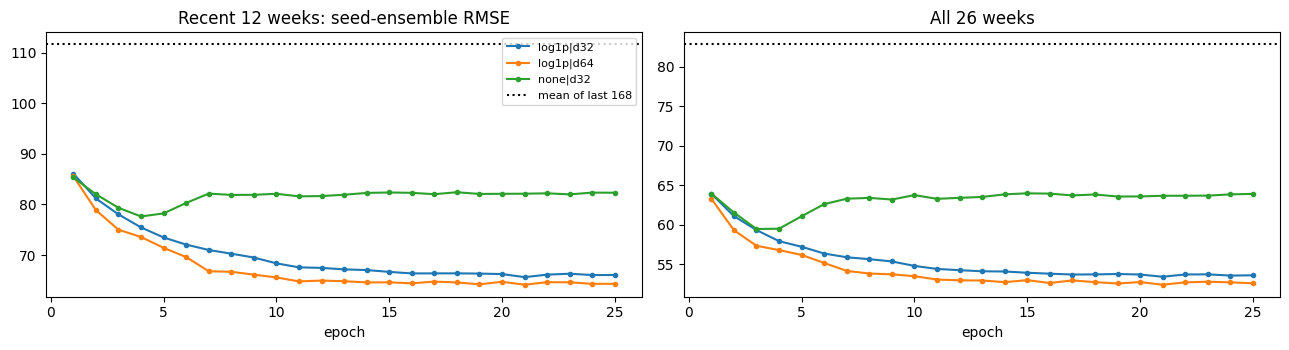

In [38]:
rows = []
for name, P_ in PRED.items():
    ens = P_.mean(0)                                                     # [epochs, 26, H]
    for e in range(ens.shape[0]):
        rows.append({"candidate": name, "epoch": e + 1, "recent RMSE": score(ens[e], RECENT),
                     "all-26 RMSE": score(ens[e], np.arange(N_EVAL_BLOCKS)),
                     "single-seed recent RMSE": np.mean([score(P_[s, e], RECENT) for s in range(P_.shape[0])])})
curves = pd.DataFrame(rows)
curves.round(3).to_csv(OUT / "epoch_curves.csv", index=False)
MIN_EPOCH = 3 if not QUICK else 1
EPOCH = {n: int(curves[(curves.candidate == n) & (curves.epoch >= MIN_EPOCH)].sort_values("recent RMSE").iloc[0]["epoch"])
         for n in PRED}
chosen = curves[[EPOCH[r.candidate] == r.epoch for r in curves.itertuples()]].set_index("candidate")
chosen["params (one model)"] = pd.Series(PARAMS)
display(chosen.round(2))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6), sharex=True)
for n in PRED:
    c = curves[curves.candidate == n]
    ax[0].plot(c.epoch, c["recent RMSE"], marker="o", ms=3, label=n)
    ax[1].plot(c.epoch, c["all-26 RMSE"], marker="o", ms=3, label=n)
ax[0].axhline(blk["baseline RMSE"].values[RECENT].mean(), color="k", ls=":", label=BEST_BASELINE)
ax[1].axhline(blk["baseline RMSE"].mean(), color="k", ls=":", label=BEST_BASELINE)
ax[0].set(title="Recent 12 weeks: seed-ensemble RMSE", xlabel="epoch"); ax[1].set(title="All 26 weeks", xlabel="epoch")
ax[0].legend(fontsize=8); plt.tight_layout(); save_fig("v2_epoch_curves")

## 8. Blend and scale, judged by leave-one-week-out cross-validation

Forecast = s · ( w · LOG + (1 − w) · RAW ), where LOG is the better log-target ensemble and RAW
the raw-target ensemble, each at its chosen epoch. The grid is w ∈ {0, 0.1, …, 1} and
s ∈ {0.90, 0.95, …, 1.40}.

Honest evaluation: for each of the 12 recent weeks, pick (w, s) using the **other 11 weeks
only**, then score the held-out week. The mean over the 12 held-out weeks estimates how the
tuned recipe does on an unseen week. Fixed recipes (plain LOG, plain RAW, 50/50) involve no
tuning, so their recent-week RMSE is already out-of-sample for (w, s).

,recent RMSE (out-of-sample),all-26 RMSE
recipe,,
"LOG only (w=1, s=1)",64.13,52.44
"RAW only (w=0, s=1)",77.63,59.51
"50/50 blend (w=0.5, s=1)",68.17,53.08
"tuned (w=1.0, s=1.2), leave-one-week-out",63.27,50.19
"v1 recipe (log1p|d32, epoch 15)",66.67,53.95


LOG ensemble = log1p|d64 (epoch 21), RAW ensemble = none|d32 (epoch 4)


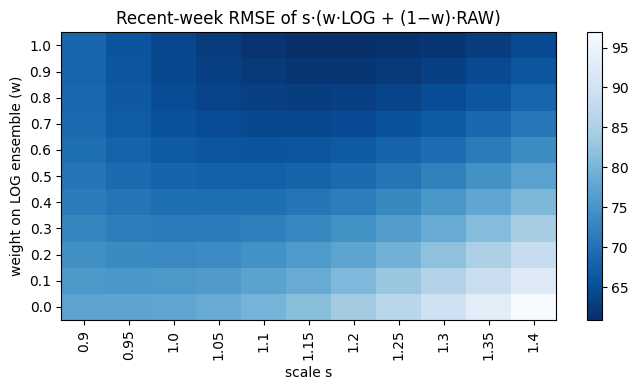

FINAL RECIPE: tuned blend  ->  w = 1.0, s = 1.2
recent-12-week RMSE: v2 60.89 (tuned recipes are reported with their cross-validated value above) vs v1 recipe 66.67 vs mean of last 168 111.64


In [39]:
LOG_NAME = min([n for n in PRED if n.startswith("log1p")], key=lambda n: chosen.loc[n, "recent RMSE"])
LOG = PRED[LOG_NAME][:, EPOCH[LOG_NAME] - 1].mean(0)                    # [26, H]
RAW = PRED["none|d32"][:, EPOCH["none|d32"] - 1].mean(0)
W_GRID, S_GRID = np.round(np.linspace(0, 1, 11), 2), np.round(np.arange(0.90, 1.401, 0.05), 2)
# per-week RMSE for every (w, s): [len(W), len(S), 26]
GRID = np.stack([np.stack([block_rmse(s * (w * LOG + (1 - w) * RAW)) for s in S_GRID]) for w in W_GRID])

def fit_ws(weeks):
    m = GRID[:, :, weeks].mean(-1)
    i, j = np.unravel_index(np.argmin(m), m.shape)
    return W_GRID[i], S_GRID[j]

cv = []
for b in RECENT:
    w, s = fit_ws([x for x in RECENT if x != b])
    cv.append(float(GRID[list(W_GRID).index(w), list(S_GRID).index(s), b]))
CV_TUNED = float(np.mean(cv))
W_FIT, S_FIT = fit_ws(list(RECENT))
fixed = {"LOG only (w=1, s=1)": (1.0, 1.0), "RAW only (w=0, s=1)": (0.0, 1.0), "50/50 blend (w=0.5, s=1)": (0.5, 1.0)}
recipe_rows = [{"recipe": k, "recent RMSE (out-of-sample)": float(GRID[list(W_GRID).index(w), list(S_GRID).index(s), RECENT].mean()),
                "all-26 RMSE": float(GRID[list(W_GRID).index(w), list(S_GRID).index(s)].mean())} for k, (w, s) in fixed.items()]
recipe_rows.append({"recipe": f"tuned (w={W_FIT}, s={S_FIT}), leave-one-week-out", "recent RMSE (out-of-sample)": CV_TUNED,
                    "all-26 RMSE": float(GRID[list(W_GRID).index(W_FIT), list(S_GRID).index(S_FIT)].mean())})
# v1 recipe on the same weeks: log1p|d32, epoch 15, seed ensemble (seeds as available)
V1 = PRED["log1p|d32"][:, min(15, PRED["log1p|d32"].shape[1]) - 1].mean(0)
recipe_rows.append({"recipe": "v1 recipe (log1p|d32, epoch 15)", "recent RMSE (out-of-sample)": score(V1, RECENT),
                    "all-26 RMSE": score(V1, np.arange(N_EVAL_BLOCKS))})
recipes = pd.DataFrame(recipe_rows).set_index("recipe")
display(recipes.round(2)); recipes.round(3).to_csv(OUT / "recipes.csv")
print(f"LOG ensemble = {LOG_NAME} (epoch {EPOCH[LOG_NAME]}), RAW ensemble = none|d32 (epoch {EPOCH['none|d32']})")

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(GRID[:, :, RECENT].mean(-1), aspect="auto", cmap="Blues_r", origin="lower")
ax.set_xticks(range(len(S_GRID))); ax.set_xticklabels(S_GRID, rotation=90)
ax.set_yticks(range(len(W_GRID))); ax.set_yticklabels(W_GRID)
ax.set(xlabel="scale s", ylabel="weight on LOG ensemble (w)", title="Recent-week RMSE of s·(w·LOG + (1−w)·RAW)")
plt.colorbar(im); plt.tight_layout(); save_fig("v2_blend_grid")

# Decision: adopt the tuned blend only if its cross-validated RMSE beats every fixed recipe.
best_fixed = recipes.drop(index=[r for r in recipes.index if r.startswith(("tuned", "v1"))])["recent RMSE (out-of-sample)"]
if CV_TUNED < best_fixed.min():
    W_FINAL, S_FINAL, RECIPE = W_FIT, S_FIT, "tuned blend"
else:
    k = best_fixed.idxmin(); W_FINAL, S_FINAL = fixed[k]; RECIPE = k
print(f"FINAL RECIPE: {RECIPE}  ->  w = {W_FINAL}, s = {S_FINAL}")
v2_val = float(GRID[list(W_GRID).index(W_FINAL), list(S_GRID).index(S_FINAL), RECENT].mean())
print(f"recent-12-week RMSE: v2 {v2_val:.2f} (tuned recipes are reported with their cross-validated value above) "
      f"vs v1 recipe {score(V1, RECENT):.2f} vs {BEST_BASELINE} {blk['baseline RMSE'].values[RECENT].mean():.2f}")

## 9. Final fit on all data and the leaderboard forecast

Each ensemble that has non-zero weight is refitted with the 5 seeds on **all** observed data,
using its chosen number of epochs. The forecast is s·(w·mean(LOG members) + (1−w)·mean(RAW members)).
P and E are summed over every model that contributes.

log1p|d64: 5 members x 21 epochs; weight 1.00


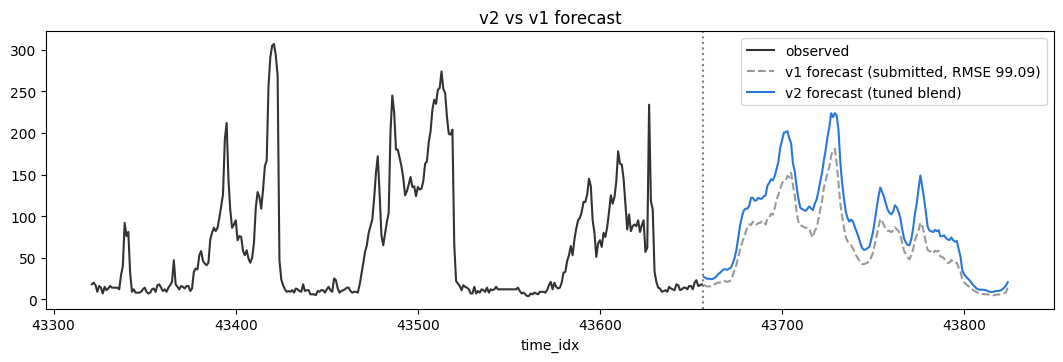

{
 "recipe": "tuned blend",
 "w_log": 1.0,
 "scale": 1.2,
 "log_model": "log1p|d64",
 "epochs": {
  "log1p|d64": 21
 },
 "seeds": [
  0,
  1,
  2,
  3,
  4
 ],
 "P_trainable_parameters": 446085,
 "E_training_epochs": 105,
 "estimated_penalty": 0.0533475615,
 "recent12_RMSE_v2": 60.89335115994829,
 "recent12_RMSE_v1_recipe": 66.66810437269952
}
mean |v2 − v1| over the 168 steps: 25.10; mean level v1 66.1 vs v2 91.2

DECLARE ON THE LEADERBOARD:  P = 446,085;  E = 105

Paste this into the predictions field:

26.8937, 25.7364, 24.5589, 24.8798, 24.1954, 24.4947, 25.6394, 27.6668, 30.4717, 32.0182, 34.1597, 36.1347, 35.9829, 35.5407, 37.0065, 38.1299, 43.6157, 49.9529, 60.0516, 74.3185, 89.1732, 99.4203, 106.7157, 108.9362, 109.0482, 112.6026, 122.0252, 122.0689, 118.4921, 119.1503, 122.0729, 120.7747, 121.1379, 123.9003, 124.9953, 136.7758, 140.0921, 144.4435, 143.0394, 148.3066, 156.4874, 165.4811, 182.1960, 190.7471, 200.2965, 200.9664, 202.1306, 193.7393, 187.6514, 163.1354, 153.7767, 1

In [40]:
members = []
if W_FINAL > 0:
    members.append((LOG_NAME, W_FINAL))
if W_FINAL < 1:
    members.append(("none|d32", 1 - W_FINAL))
FINAL_SEEDS_V2 = FINAL_SEEDS if not QUICK else FINAL_SEEDS[:2]
P_DECLARED, E_DECLARED, parts, member_fc = 0, 0, [], {}
for name, weight in members:
    fcs = []
    for s in FINAL_SEEDS_V2:
        m, b, info = train_model(CANDS[name], s, N, EPOCH[name], verbose=False)
        fcs.append(predict(m, b, np.array([N]))[0])
        P_DECLARED += n_params(m); E_DECLARED += info["epochs_run"]
        torch.save(m.state_dict(), OUT / f"final_{name.replace('|', '_')}_seed{s}.pt")
    member_fc[name] = np.stack(fcs)
    parts.append(weight * member_fc[name].mean(0))
    print(f"{name}: {len(fcs)} members x {EPOCH[name]} epochs; weight {weight:.2f}")
forecast = np.clip(S_FINAL * np.sum(parts, 0), 0, None)
assert forecast.shape == (H,) and np.isfinite(forecast).all()

V1_FORECAST = np.array([17.1666, 16.3998, 15.3388, 15.8506, 15.4527, 16.1726, 18.3869, 19.2808, 20.1034, 20.2042, 21.0268, 22.3970, 21.6232, 20.8365, 21.9261, 22.7297, 29.0423, 35.0658, 41.8236, 51.3508, 60.0936, 67.5546, 74.1720, 80.3565, 87.4381, 90.2702, 89.3769, 93.3616, 89.7064, 89.9712, 91.7236, 91.8373, 94.3351, 93.2983, 89.9002, 97.4186, 98.5096, 102.9576, 101.6993, 109.5970, 119.8267, 125.6967, 133.1115, 139.3378, 143.0191, 143.3236, 148.4803, 146.4024, 152.1852, 137.0172, 125.1918, 104.3785, 93.0821, 88.3267, 88.5009, 86.9095, 85.8072, 86.2959, 84.7104, 78.6100, 74.3865, 82.1576, 85.9601, 96.1214, 107.8053, 118.6471, 134.4307, 142.6493, 151.8889, 159.4046, 173.0234, 178.3952, 181.0343, 163.6526, 140.6311, 115.4254, 99.6965, 86.7843, 75.0859, 69.6080, 66.6298, 64.9423, 60.9417, 55.7910, 51.7016, 48.2302, 44.6160, 42.2797, 42.3027, 43.1137, 44.2628, 45.5134, 50.9694, 56.2061, 66.7324, 77.1997, 87.1617, 96.7134, 93.7622, 89.0740, 83.9006, 82.2024, 82.4770, 80.7014, 82.8529, 86.7954, 84.0239, 82.3049, 77.1177, 67.6288, 58.6085, 53.8727, 50.3424, 48.1220, 52.8468, 60.3479, 70.9934, 76.9707, 82.8999, 92.1346, 87.8875, 79.8332, 68.3126, 59.2223, 57.8383, 57.1065, 54.9213, 58.3318, 57.4394, 58.4676, 51.3686, 50.8969, 49.3100, 45.3800, 43.7520, 44.1755, 47.2773, 44.6760, 43.4103, 43.9971, 38.2010, 33.3642, 23.8963, 20.2707, 18.2717, 16.3622, 14.7753, 13.0335, 11.2278, 9.8051, 8.3603, 7.5643, 6.9615, 6.4481, 6.1559, 6.0147, 5.9392, 4.9075, 4.6413, 4.7569, 5.3950, 5.6173, 5.8601, 5.9845, 6.7703, 7.3568, 8.1287, 14.6177])
sub = pd.DataFrame({"time_idx": test_df.time_idx.values, "value": forecast})
sub.to_csv(OUT / "submission_forecast_v2.csv", index=False)
paste = ", ".join(f"{v:.4f}" for v in forecast)
(OUT / "leaderboard_paste_v2.txt").write_text(paste)
meta = {"recipe": RECIPE, "w_log": W_FINAL, "scale": S_FINAL, "log_model": LOG_NAME,
        "epochs": {k: EPOCH[k] for k, _ in members}, "seeds": FINAL_SEEDS_V2,
        "P_trainable_parameters": P_DECLARED, "E_training_epochs": E_DECLARED,
        "estimated_penalty": ALPHA_HAT * P_DECLARED + BETA_HAT * E_DECLARED,
        "recent12_RMSE_v2": v2_val, "recent12_RMSE_v1_recipe": score(V1, RECENT)}
(OUT / "submission_meta_v2.json").write_text(json.dumps(meta, indent=1, default=float))

fig, ax = plt.subplots(figsize=(13, 3.6))
ax.plot(np.arange(N - 2 * H, N) + 1, y_raw[-2 * H:], color="#333", label="observed")
ax.plot(test_df.time_idx.values, V1_FORECAST, color="#999", ls="--", label="v1 forecast (submitted, RMSE 99.09)")
ax.plot(test_df.time_idx.values, forecast, color="#2a78d6", label=f"v2 forecast ({RECIPE})")
ax.axvline(N + 0.5, color="grey", ls=":"); ax.set(xlabel="time_idx", title="v2 vs v1 forecast"); ax.legend()
save_fig("v2_final_forecast")

print(json.dumps(meta, indent=1, default=float))
print(f"mean |v2 − v1| over the 168 steps: {np.abs(forecast - V1_FORECAST).mean():.2f}; "
      f"mean level v1 {V1_FORECAST.mean():.1f} vs v2 {forecast.mean():.1f}")
print(f"\nDECLARE ON THE LEADERBOARD:  P = {P_DECLARED:,};  E = {E_DECLARED}")
print("\nPaste this into the predictions field:\n")
print(paste)